# Bộ dữ liệu 

Retailrocket recommender system dataset

Bộ dữ liệu bao gồm ba tệp: 

    Tệp chứa dữ liệu hành vi (events.csv), 

    tệp chứa thuộc tính mặt hàng (item_properties.csv)  
 
    tệp mô tả cây danh mục (category_tree.csv). 
 
 Dữ liệu được thu thập từ một trang web thương mại điện tử thực tế. Đây là dữ liệu thô, tức là không qua bất kỳ chuyển đổi nội dung nào, tuy nhiên, tất cả các giá trị đều được mã hóa băm do vấn đề bảo mật. Mục đích công bố là để thúc đẩy các nghiên cứu trong lĩnh vực hệ thống đề xuất với phản hồi ngầm.

NỘI DUNG

Dữ liệu hành vi, tức là các sự kiện như nhấp chuột, thêm vào giỏ hàng, giao dịch, thể hiện các tương tác được thu thập trong khoảng thời gian 4,5 tháng. Một khách truy cập có thể thực hiện ba loại sự kiện, đó là "xem", "thêm vào giỏ hàng" hoặc "giao dịch". Tổng cộng có 2.756.101 sự kiện, bao gồm 2.664.312 lượt xem, 69.332 lượt thêm vào giỏ hàng và 22.457 giao dịch được thực hiện bởi 1.407.580 khách truy cập duy nhất. Đối với khoảng 90% sự kiện, các thuộc tính tương ứng có thể được tìm thấy trong tệp "item_properties.csv".

Tệp thuộc tính mặt hàng chứa cột dấu thời gian vì tất cả các thuộc tính đều phụ thuộc vào thời gian, do chúng có thể thay đổi theo thời gian, ví dụ như giá cả, danh mục, v.v. Ban đầu, tệp này bao gồm các bản ghi nhanh cho mỗi tuần trong tệp sự kiện và chứa hơn 200 triệu dòng. Chúng tôi đã hợp nhất các giá trị thuộc tính không đổi liên tiếp, do đó nó đã được chuyển từ dạng bản ghi nhanh sang dạng nhật ký thay đổi. Vì vậy, các giá trị không đổi sẽ chỉ xuất hiện một lần trong tệp. Hành động này đã giảm đáng kể số lượng dòng xuống còn 1/10.

Tất cả các giá trị trong tệp “item_properties.csv”, ngoại trừ thuộc tính “categoryid” và “available”, đều được băm. Giá trị của thuộc tính “categoryid” chứa mã định danh danh mục mặt hàng. Giá trị của thuộc tính “available” chứa thông tin về tình trạng sẵn có của mặt hàng, ví dụ: 1 nghĩa là mặt hàng có sẵn, ngược lại là 0. 

Tệp cây danh mục có 1669 hàng. Mỗi hàng trong tệp chỉ định một ID danh mục con và danh mục cha tương ứng.


1. Khai báo thư viện


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder  
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.nn.utils.rnn import pack_padded_sequence
import torch.nn as nn
import torch
from collections import defaultdict
import time
import random
import pickle


In [17]:
# Dữ liệu hành vi
data_events = pd.read_csv("/kaggle/input/datasets/nguyenkin/dataset/events.csv")
data_events


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN
...,...,...,...,...,...
2756096,1438398785939,591435,view,261427,NaN
2756097,1438399813142,762376,view,115946,NaN
2756098,1438397820527,1251746,view,78144,NaN
2756099,1438398530703,1184451,view,283392,NaN


In [18]:
#Dữ liệu cây danh mục
data_categorytree = pd.read_csv("/kaggle/input/datasets/nguyenkin/dataset/category_tree.csv")
data_categorytree

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0
...,...,...
1664,49,1125.0
1665,1112,630.0
1666,1336,745.0
1667,689,207.0


In [19]:
#Dữ liệu thuộc tính mặt hàng
data_item1 = pd.read_csv("/kaggle/input/datasets/nguyenkin/dataset/item_properties_part1.csv")
data_item1

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513
...,...,...,...,...
10999994,1439694000000,86599,categoryid,618
10999995,1435460400000,153032,1066,n1020.000 424566
10999996,1440298800000,421788,888,35975 856003 37346
10999997,1437879600000,159792,400,n552.000 639502 n720.000 424566


In [20]:
#Dữ liệu thuộc tính mặt hàng
data_item2 = pd.read_csv("/kaggle/input/datasets/nguyenkin/dataset/item_properties_part2.csv")
data_item2

,timestamp,itemid,property,value
0,1433041200000,183478,561,769062
1,1439694000000,132256,976,n26.400 1135780
2,1435460400000,420307,921,1149317 1257525
3,1431831600000,403324,917,1204143
4,1435460400000,230701,521,769062
...,...,...,...,...
9275898,1433646000000,236931,929,n12.000
9275899,1440903600000,455746,6,150169 639134
9275900,1439694000000,347565,686,610834
9275901,1433646000000,287231,867,769062


2. Xử lý dữ liệu


Với file item_properties_part1.csv 


Vì ở file category_tree chỉ có categoryid



In [21]:
# Lọc property chỉ còn categoryid, available
data_item1 = data_item1[data_item1["property"].isin(["categoryid", "available"])]
data_item1

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
5,1436065200000,285026,available,0
15,1437274800000,186518,available,0
79,1433646000000,423682,available,0
82,1434250800000,316253,available,1
...,...,...,...,...
10999959,1442113200000,362293,available,1
10999960,1431226800000,84186,categoryid,209
10999986,1439089200000,259404,available,1
10999991,1436065200000,375264,available,1


In [22]:
# Lọc property chỉ còn categoryid, available
data_item2 = data_item2[data_item2["property"].isin(["categoryid", "available"])]
data_item2

,timestamp,itemid,property,value
15,1431226800000,8921,categoryid,1188
31,1433041200000,352564,available,0
43,1431831600000,106601,available,0
65,1437274800000,17166,available,1
70,1433041200000,122405,categoryid,769
...,...,...,...,...
9275873,1435460400000,444741,categoryid,511
9275879,1435460400000,97513,categoryid,1385
9275890,1433041200000,356167,available,0
9275892,1439089200000,200211,available,0


In [23]:
# Gộp 2 file item
data_item = pd.concat([data_item1, data_item2])
data_item

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
5,1436065200000,285026,available,0
15,1437274800000,186518,available,0
79,1433646000000,423682,available,0
82,1434250800000,316253,available,1
...,...,...,...,...
9275873,1435460400000,444741,categoryid,511
9275879,1435460400000,97513,categoryid,1385
9275890,1433041200000,356167,available,0
9275892,1439089200000,200211,available,0


In [24]:
# convert timestamp 
data_item["timestamp"] = pd.to_datetime(data_item["timestamp"], unit="ms") 
# sort 
data_item = data_item.sort_values("timestamp") 
data_item = data_item.groupby(["itemid", "property"]).last().reset_index()
data_item

,itemid,property,timestamp,value
0,0,available,2015-05-17 03:00:00,0
1,0,categoryid,2015-05-10 03:00:00,209
2,1,available,2015-09-13 03:00:00,0
3,1,categoryid,2015-05-10 03:00:00,1114
4,2,available,2015-06-28 03:00:00,0
...,...,...,...,...
834101,466864,categoryid,2015-05-10 03:00:00,373
834102,466865,available,2015-06-28 03:00:00,0
834103,466865,categoryid,2015-05-10 03:00:00,421
834104,466866,available,2015-05-24 03:00:00,0


In [25]:
# pivot
data_item = data_item.pivot(
    index="itemid",
    columns="property",
    values="value",
).reset_index()
data_item

property,itemid,available,categoryid
0,0,0,209
1,1,0,1114
2,2,0,1305
3,3,0,1171
4,4,0,1038
...,...,...,...
417048,466862,0,1376
417049,466863,0,173
417050,466864,0,373
417051,466865,0,421


File event.csv


In [26]:
# Loại bỏ cột transactionid
data_events = data_events[["visitorid", "itemid", "timestamp", "event"]]
data_events

,visitorid,itemid,timestamp,event
0,257597,355908,1433221332117,view
1,992329,248676,1433224214164,view
2,111016,318965,1433221999827,view
3,483717,253185,1433221955914,view
4,951259,367447,1433221337106,view
...,...,...,...,...
2756096,591435,261427,1438398785939,view
2756097,762376,115946,1438399813142,view
2756098,1251746,78144,1438397820527,view
2756099,1184451,283392,1438398530703,view


In [27]:
# Chuyển từ dạng số sang dạng thời gian
data_events["timestamp"] = pd.to_datetime(data_events["timestamp"], unit="ms")
#Sắp xếp theo thời gian,user
data_events = data_events.sort_values(["visitorid", "timestamp"])
data_events

/tmp/ipykernel_55/2440702269.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_events["timestamp"] = pd.to_datetime(data_events["timestamp"], unit="ms")


,visitorid,itemid,timestamp,event
1361687,0,285930,2015-09-11 20:49:49.439,view
1367212,0,357564,2015-09-11 20:52:39.591,view
1367342,0,67045,2015-09-11 20:55:17.175,view
830385,1,72028,2015-08-13 17:46:06.444,view
742616,2,325215,2015-08-07 17:51:44.567,view
...,...,...,...,...
206556,1407575,121220,2015-06-10 21:46:08.922,view
47311,1407576,356208,2015-06-03 15:01:29.991,view
1762583,1407577,427784,2015-05-17 21:48:04.867,view
1744277,1407578,188736,2015-05-17 01:21:23.288,view


In [28]:
# Ghép file item + event
df_eventitem = data_events.merge(data_item, on="itemid", how="left")
df_eventitem

,visitorid,itemid,timestamp,event,available,categoryid
0,0,285930,2015-09-11 20:49:49.439,view,1,1188
1,0,357564,2015-09-11 20:52:39.591,view,1,256
2,0,67045,2015-09-11 20:55:17.175,view,1,333
3,1,72028,2015-08-13 17:46:06.444,view,0,1192
4,2,325215,2015-08-07 17:51:44.567,view,1,299
...,...,...,...,...,...,...
2756096,1407575,121220,2015-06-10 21:46:08.922,view,0,1221
2756097,1407576,356208,2015-06-03 15:01:29.991,view,0,175
2756098,1407577,427784,2015-05-17 21:48:04.867,view,0,1237
2756099,1407578,188736,2015-05-17 01:21:23.288,view,0,1584


In [29]:
# Kiểm tra dữ liệu trống
df_eventitem.isnull().sum()

visitorid          0
itemid             0
timestamp          0
event              0
available     255585
categoryid    255585
dtype: int64

In [30]:
# Thay giá trị  trống bằng -1
df_eventitem["categoryid"] = df_eventitem["categoryid"].fillna(-1)
df_eventitem["available"] = df_eventitem["available"].fillna(-1)
df_eventitem.isnull().sum()

visitorid     0
itemid        0
timestamp     0
event         0
available     0
categoryid    0
dtype: int64

In [31]:
# Tạo chuỗi theo mã người dùng
user_sequences = df_eventitem.groupby("visitorid")["itemid"].apply(list)
user_sequences

visitorid
0                                    [285930, 357564, 67045]
1                                                    [72028]
2          [325215, 325215, 259884, 216305, 342816, 34281...
3                                                   [385090]
4                                                   [177677]
                                 ...                        
1407575                                             [121220]
1407576                                             [356208]
1407577                                             [427784]
1407578                                             [188736]
1407579                                               [2521]
Name: itemid, Length: 1407580, dtype: object

In [32]:
# Lọc các chuỗi có độ dài > 1
user_sequences_filtered = user_sequences[user_sequences.str.len() > 1]
user_sequences_filtered

visitorid
0                                    [285930, 357564, 67045]
2          [325215, 325215, 259884, 216305, 342816, 34281...
6            [65273, 253615, 344723, 344723, 344723, 344723]
7                                   [139394, 164941, 226353]
13                                          [320589, 278689]
                                 ...                        
1407537                                     [156770, 156770]
1407560                                     [240708, 240708]
1407567                                     [183650, 219086]
1407572                                     [122041, 122041]
1407573    [13961, 232069, 116453, 235724, 57720, 363109,...
Name: itemid, Length: 406020, dtype: object

3. Huấn luyện

In [33]:
# Lấy item duy nhất trong dataset
all_items = sorted({item for seq in user_sequences_filtered for item in seq})
# Map item_id
item2idx = {item: idx + 1 for idx, item in enumerate(all_items)}
# convert sequence từ item_id → index
idx2item = {idx: item for item, idx in item2idx.items()}

vocab_size = len(all_items)

print(f"Vocab size: {vocab_size:,} items")   

# Convert sang index
sequences_idx = [[item2idx[item] for item in seq] for seq in user_sequences_filtered]



Vocab size: 166,753 items


In [34]:
train_samples = []
val_samples = []
test_samples = []
max_len =20
for seq in sequences_idx:
    if len(seq) < 3:
        continue

    train_seq = seq[:-2]

    for i in range(1, len(train_seq)):
        input_seq = train_seq[max(0, i - max_len):i]
        target = train_seq[i]
        train_samples.append((input_seq, target))

        if len(train_samples) >= 500000:
            break

    if len(train_samples) >= 500000:
        break

    val_samples.append((seq[:-2][-max_len:], seq[-2]))
    test_samples.append((seq[:-1][-max_len:], seq[-1]))

In [35]:
class SimpleSeqDataset(Dataset):
    def __init__(self, samples, max_len=20):
        self.samples = samples
        self.max_len = max_len
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        input_seq, target = self.samples[idx]

        # truncate
        if len(input_seq) > self.max_len:
            input_seq = input_seq[-self.max_len:]

        return (
            torch.tensor(input_seq, dtype=torch.long),   
            torch.tensor(target, dtype=torch.long)
        )

def collate_fn(batch):
    inputs, targets = zip(*batch)

    inputs_padded = pad_sequence(
        inputs, 
        batch_first=True, 
        padding_value=0
    ).contiguous()   

    targets = torch.stack(targets)

    return inputs_padded, targets

dataset = SimpleSeqDataset(train_samples, max_len=20)

train_loader = DataLoader(
    dataset,
    batch_size=256,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True   
)

print(f"Số batches mỗi epoch: {len(train_loader)}")
# Validation dataset
val_dataset = SimpleSeqDataset(val_samples, max_len=20)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    collate_fn=collate_fn
)

# Test dataset
test_dataset = SimpleSeqDataset(test_samples, max_len=20)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    collate_fn=collate_fn
)

class SimpleLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128):
        super().__init__()

    
        self.embedding = nn.Embedding(vocab_size + 2, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            embed_dim, 
            hidden_dim, 
            batch_first=True, 
            num_layers=1
        )

        self.fc = nn.Linear(hidden_dim, vocab_size + 2)

    def forward(self, x):
        # x: (batch, seq_len)

        mask = (x != 0)
        lengths = mask.sum(dim=1)

  
        lengths = torch.clamp(lengths, min=1)

        x_embed = self.embedding(x)

        packed = pack_padded_sequence(
            x_embed,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (h, _) = self.lstm(packed)

        # lấy hidden cuối
        last_hidden = h[-1]

        logits = self.fc(last_hidden)

        return logits

Số batches mỗi epoch: 1954


In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleLSTM(vocab_size).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    model.train()
    total_loss = 0

    for inputs, targets in train_loader:
        inputs = inputs.to(device, non_blocking=True)   
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(inputs)
        loss = criterion(logits, targets)

        loss.backward()

        # chống explode gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 9.9664
Epoch 2, Loss: 7.4573
Epoch 3, Loss: 6.0723
Epoch 4, Loss: 5.1334
Epoch 5, Loss: 4.4314
Epoch 6, Loss: 3.8835
Epoch 7, Loss: 3.4513
Epoch 8, Loss: 3.1129
Epoch 9, Loss: 2.8443
Epoch 10, Loss: 2.6219


In [37]:
def evaluate(model, loader, k=10):
    model.eval()
    HR, NDCG = [], []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            logits = model(inputs)
            topk = torch.topk(logits, k=k).indices

            for i in range(len(targets)):
                pred = topk[i].tolist()
                target = targets[i].item()

                if target in pred:
                    HR.append(1)
                    rank = pred.index(target)
                    NDCG.append(1 / np.log2(rank + 2))
                else:
                    HR.append(0)
                    NDCG.append(0)

    return np.mean(HR), np.mean(NDCG)
def evaluate_fast(model, loader, k=10):
    model.eval()
    HR, NDCG = [], []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            logits = model(inputs)
            topk = torch.topk(logits, k=k).indices

            targets = targets.view(-1, 1)

            hits = (topk == targets)

            hit_any = hits.any(dim=1)

            HR.extend(hit_any.float().cpu().numpy())

            for i, row in enumerate(hits):
                if hit_any[i]:
                    rank = torch.where(row)[0][0].item()
                    NDCG.append(1 / np.log2(rank + 2))
                else:
                    NDCG.append(0)

    return np.mean(HR), np.mean(NDCG)


In [38]:
hr, ndcg = evaluate(model, val_loader, k=10)
print(f"HR@10: {hr:.4f}")
print(f"NDCG@10: {ndcg:.4f}")

HR@10: 0.3842
NDCG@10: 0.3049


In [39]:
hr, ndcg = evaluate(model, test_loader, k=10)
print(f"HR@10: {hr:.4f}")
print(f"NDCG@10: {ndcg:.4f}")

HR@10: 0.3604
NDCG@10: 0.2828


Mô hình đạt HR@10 = 0.3842 trên validation và 0.3604 trên test,
cho thấy khả năng tổng quát hóa tốt và không bị overfitting.

Data Augmentation


In [40]:
def crop(seq):
    if len(seq) <= 2:
        return seq

    start = random.randint(0, len(seq) - 2)
    end = random.randint(start + 1, len(seq))

    return seq[start:end]

In [41]:
MASK_TOKEN = vocab_size + 1
def mask(seq, prob=0.2):
    if len(seq) <= 1:
        return seq

    masked = [
        item if random.random() > prob else MASK_TOKEN
        for item in seq
    ]

    # tránh mask hết
    if all(x == MASK_TOKEN for x in masked):
        idx = random.randint(0, len(seq)-1)
        masked[idx] = seq[idx]

    return masked

In [42]:
def reorder(seq, window=3, n_times=2):
    seq = seq.copy()

    if len(seq) < window:
        return seq

    for _ in range(n_times):
        start = random.randint(0, len(seq)-window)
        sub = seq[start:start+window]
        random.shuffle(sub)
        seq[start:start+window] = sub

    return seq

In [43]:
def substitute(seq, item2cat, cat2items, prob=0.2):
    new_seq = []
    for item in seq:
        if random.random() < prob:
            cat = item2cat.get(item)

            if cat is not None and cat in cat2items:
                new_item = random.choice(cat2items[cat])
                new_seq.append(new_item)
            else:
                new_seq.append(item)
        else:
            new_seq.append(item)

    return new_seq

In [44]:
class AugDataset(Dataset):
    def __init__(
        self, 
        samples, 
        aug_type=None, 
        item2cat=None, 
        cat2items=None,
        max_len=20,
        aug_prob=0.5
    ):
        self.samples = samples
        self.aug_type = aug_type
        self.item2cat = item2cat
        self.cat2items = cat2items
        self.max_len = max_len
        self.aug_prob = aug_prob

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        input_seq, target = self.samples[idx]

        if self.aug_type and random.random() < self.aug_prob:

            if self.aug_type == "crop":
                input_seq = crop(input_seq)

            elif self.aug_type == "mask":
                input_seq = mask(input_seq)

            elif self.aug_type == "reorder":
                input_seq = reorder(input_seq)

            elif self.aug_type == "substitute":
                if self.item2cat and self.cat2items:
                    input_seq = substitute(input_seq, self.item2cat, self.cat2items)

        if len(input_seq) > self.max_len:
            input_seq = input_seq[-self.max_len:]

        return (
            torch.tensor(input_seq, dtype=torch.long),
            torch.tensor(target, dtype=torch.long)
        )

In [45]:
# 1. build mapping 
item2cat_raw = dict(zip(data_item["itemid"], data_item["categoryid"]))
item2cat_idx = {
    item2idx[item]: int(cat)   # ✅ ép int
    for item, cat in item2cat_raw.items()
    if item in item2idx and pd.notna(cat)
}
cat2items_idx = defaultdict(list)
for item, cat in item2cat_raw.items():
    if item in item2idx and pd.notna(cat):
        cat2items_idx[int(cat)].append(item2idx[item])  # ✅ ép int
cat2items_idx = {
    cat: items
    for cat, items in cat2items_idx.items()
    if len(items) > 0
}
# lọc category ít item
for cat in list(cat2items_idx.keys()):
    if len(cat2items_idx[cat]) < 2:
        del cat2items_idx[cat]

# 2. dataset
train_dataset = AugDataset(
    train_samples,
    aug_type="substitute",
    item2cat=item2cat_idx,
    cat2items=cat2items_idx,
    aug_prob=0.3
)

# 3. dataloader
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

# 4. model
model = SimpleLSTM(vocab_size).to(device)

In [46]:
def train(model, train_loader, optimizer, criterion, epochs=10):
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            logits = model(inputs)
            loss = criterion(logits, targets)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")


results = []


In [47]:

for aug in [None, "crop", "mask", "reorder", "substitute"]:
    print("Running:", aug)

    if aug is None:
        train_dataset = SimpleSeqDataset(train_samples)
    elif aug == "substitute":
        train_dataset = AugDataset(
            train_samples,
            aug_type=aug,
            item2cat=item2cat_idx,
            cat2items=cat2items_idx
        )
    else:
        train_dataset = AugDataset(train_samples, aug_type=aug)

    train_loader = DataLoader(
        train_dataset,
        batch_size=256,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=2,
        pin_memory=True
    )

    model = SimpleLSTM(vocab_size).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(ignore_index=0)

    train(model, train_loader, optimizer, criterion)

    hr, ndcg = evaluate(model, test_loader)

    print(aug, hr, ndcg)

    results.append((aug if aug else "Baseline", hr, ndcg))

Running: None
Epoch 1, Loss: 9.9697
Epoch 2, Loss: 7.4602
Epoch 3, Loss: 6.0680
Epoch 4, Loss: 5.1263
Epoch 5, Loss: 4.4232
Epoch 6, Loss: 3.8715
Epoch 7, Loss: 3.4401
Epoch 8, Loss: 3.1010
Epoch 9, Loss: 2.8340
Epoch 10, Loss: 2.6110
None 0.35996935855744894 0.2815272997310061
Running: crop
Epoch 1, Loss: 10.1526
Epoch 2, Loss: 8.0001
Epoch 3, Loss: 6.8615
Epoch 4, Loss: 6.0992
Epoch 5, Loss: 5.5385
Epoch 6, Loss: 5.1042
Epoch 7, Loss: 4.7575
Epoch 8, Loss: 4.4910
Epoch 9, Loss: 4.2693
Epoch 10, Loss: 4.1003
crop 0.38643515354516983 0.3019181993630377
Running: mask
Epoch 1, Loss: 10.0483
Epoch 2, Loss: 7.6549
Epoch 3, Loss: 6.3285
Epoch 4, Loss: 5.4395
Epoch 5, Loss: 4.7796
Epoch 6, Loss: 4.2693
Epoch 7, Loss: 3.8668
Epoch 8, Loss: 3.5471
Epoch 9, Loss: 3.2975
Epoch 10, Loss: 3.0906
mask 0.37311964431894135 0.29180509710919594
Running: reorder
Epoch 1, Loss: 9.9769
Epoch 2, Loss: 7.4745
Epoch 3, Loss: 6.0971
Epoch 4, Loss: 5.1744
Epoch 5, Loss: 4.4905
Epoch 6, Loss: 3.9631
Epoch 7, Lo

In [48]:
for name, hr, ndcg in results:
    print(f"{name:12} | HR@10: {hr:.4f} | NDCG@10: {ndcg:.4f}")

Baseline     | HR@10: 0.3600 | NDCG@10: 0.2815
crop         | HR@10: 0.3864 | NDCG@10: 0.3019
mask         | HR@10: 0.3731 | NDCG@10: 0.2918
reorder      | HR@10: 0.3641 | NDCG@10: 0.2856
substitute   | HR@10: 0.3836 | NDCG@10: 0.2990


In [49]:
base_hr, base_ndcg = results[0][1], results[0][2]

for name, hr, ndcg in results[1:]:
    print(f"{name}: HR +{(hr-base_hr)/base_hr*100:.2f}% | NDCG +{(ndcg-base_ndcg)/base_ndcg*100:.2f}%")

crop: HR +7.35% | NDCG +7.24%
mask: HR +3.65% | NDCG +3.65%
reorder: HR +1.14% | NDCG +1.44%
substitute: HR +6.57% | NDCG +6.20%


In [50]:
labels = [name for name, _, _ in results]
hr_scores = [hr for _, hr, _ in results]
ndcg_scores = [ndcg for _, _, ndcg in results]

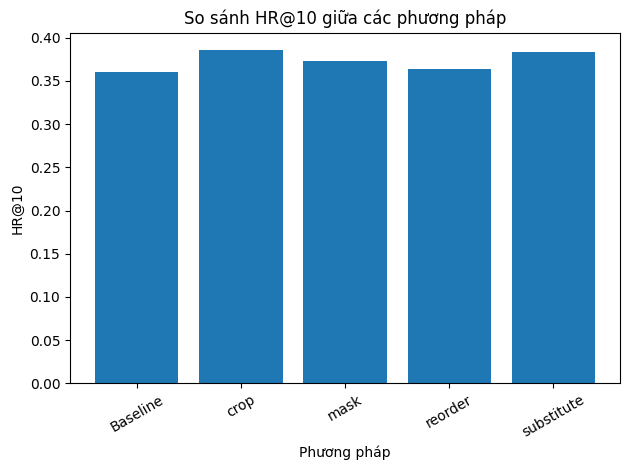

In [51]:
plt.figure()
plt.bar(labels, hr_scores)

plt.title("So sánh HR@10 giữa các phương pháp")
plt.xlabel("Phương pháp")
plt.ylabel("HR@10")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

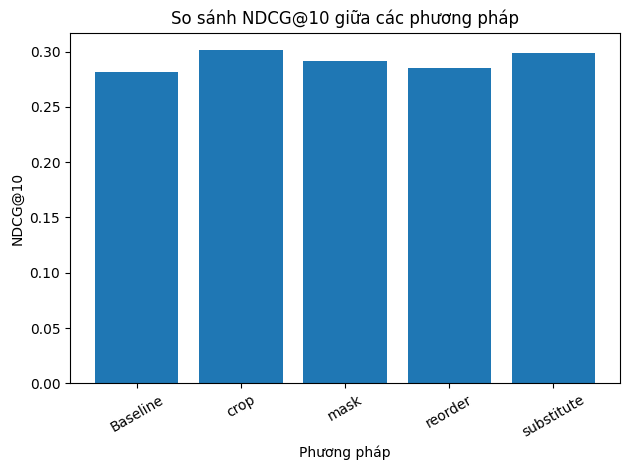

In [52]:
plt.figure()
plt.bar(labels, ndcg_scores)

plt.title("So sánh NDCG@10 giữa các phương pháp")
plt.xlabel("Phương pháp")
plt.ylabel("NDCG@10")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [53]:
# 1. lưu model
torch.save(model.state_dict(), "/kaggle/working/model.pth")
# 2. lưu mapping
pickle.dump(item2idx, open("/kaggle/working/item2idx.pkl", "wb"))
pickle.dump(idx2item, open("/kaggle/working/idx2item.pkl", "wb"))
print("Đã lưu model!")

Đã lưu model!


In [59]:
config = {
    "vocab_size": vocab_size,
    "embed_dim": 64,
    "hidden_dim": 128,
    "max_len": 20
}

pickle.dump(config, open("/kaggle/working/config.pkl", "wb"))


Data augmentation giúp cải thiện hiệu suất của mô hình sequential recommendation. Trong đó, phương pháp Mask mang lại hiệu quả tốt nhất do giúp mô hình học được ngữ cảnh khi một phần dữ liệu bị thiếu. Substitute cũng cải thiện đáng kể nhờ khai thác thông tin tương đồng giữa các item. Ngược lại, Crop và Reorder chỉ mang lại cải thiện nhẹ do làm mất hoặc xáo trộn thông tin trong chuỗi.